# What Predicts Developer Compensation?

## A 2025 Stack Overflow Developer Survey Analysis

This project applies the CRISP-DM process to investigate compensation among
professional developers. It answers four business questions:

1. How does annual compensation vary across experience levels, countries, and
   developer roles?
2. Which technologies are conditionally associated with higher or lower
   compensation after accounting for career and workplace context?
3. How accurately can compensation be predicted from public survey responses,
   and which features contribute most to predictive performance?
4. What does the selected model predict for three hypothetical career profiles?

The target is `ConvertedCompYearly`, modeled as
`log1p(ConvertedCompYearly)`. All findings are observational associations from
a self-selected survey; they are not causal salary effects or individual
salary advice.

In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path

from matplotlib.ticker import MaxNLocator, StrMethodFormatter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "results.csv"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "ConvertedCompYearly"
RANDOM_STATE = 42

## CRISP-DM 1–2: Business and Data Understanding

The analysis uses the official 2025 Stack Overflow Developer Survey response
file. The population is restricted to respondents who identify as developers
by profession, are employed or independent/freelance/self-employed, and report
positive annual compensation.

For the primary analysis, compensation must be between USD 1,000 and USD
1,000,000, inclusive. This transparent plausibility rule retains 97.7% of the
approved working-professional population while limiting likely unit-entry and
currency-conversion errors. A stricter USD 2,500–500,000 sensitivity range is
evaluated later.

## Training-only multi-select encoding

Technology answers are semicolon-delimited lists. The custom transformer below
learns its technology vocabulary from each training fold, keeps options with at
least 200 training respondents, and adds a missing indicator for each family.
This prevents feature-vocabulary leakage from validation and test data.

In [2]:
class MultiSelectEncoder(BaseEstimator, TransformerMixin):
    '''Encode semicolon-delimited multi-select survey columns.'''

    def __init__(self, min_frequency=200, separator=";"):
        self.min_frequency = min_frequency
        self.separator = separator

    def fit(self, X, y=None):
        '''Learn frequent options separately for every input column.'''
        frame = self._to_frame(X)
        self.columns_ = list(frame.columns)
        self.vocabularies_ = {}
        self.feature_names_ = []

        for column in self.columns_:
            counts = Counter()
            for value in frame[column].dropna():
                counts.update(self._split(value))
            vocabulary = sorted(
                option
                for option, count in counts.items()
                if count >= self.min_frequency
            )
            self.vocabularies_[column] = vocabulary
            self.feature_names_.extend(
                f"{column}__{option}" for option in vocabulary
            )
            self.feature_names_.append(f"{column}__Missing")
        return self

    def transform(self, X):
        '''Transform values into dense binary indicators.'''
        frame = self._to_frame(X)
        blocks = []

        for column in self.columns_:
            vocabulary = self.vocabularies_[column]
            index = {option: position for position, option in enumerate(vocabulary)}
            block = np.zeros((len(frame), len(vocabulary) + 1), dtype=np.float32)

            for row_position, value in enumerate(frame[column]):
                if pd.isna(value):
                    block[row_position, -1] = 1.0
                    continue
                for option in self._split(value):
                    option_position = index.get(option)
                    if option_position is not None:
                        block[row_position, option_position] = 1.0
            blocks.append(block)

        return np.hstack(blocks)

    def get_feature_names_out(self, input_features=None):
        '''Return output names for ColumnTransformer.'''
        return np.asarray(self.feature_names_, dtype=object)

    def _split(self, value):
        '''Split one survey response and remove empty options.'''
        return [
            option.strip()
            for option in str(value).split(self.separator)
            if option.strip()
        ]

    def _to_frame(self, X):
        '''Convert transformer input to a DataFrame with stable columns.'''
        if isinstance(X, pd.DataFrame):
            return X.copy()
        columns = getattr(self, "columns_", None)
        return pd.DataFrame(X, columns=columns)

In [3]:
survey = pd.read_csv(DATA_PATH, low_memory=False)

professional = survey["MainBranch"].eq("I am a developer by profession")
working = survey["Employment"].isin(
    [
        "Employed",
        "Independent contractor, freelancer, or self-employed",
    ]
)
positive_compensation = survey[TARGET].gt(0)
plausible_compensation = survey[TARGET].between(1_000, 1_000_000)

model_data = survey.loc[
    professional & working & positive_compensation & plausible_compensation
].copy()

print(f"Primary modeling rows: {len(model_data):,}")
print(
    "Rows removed by the approved plausibility range: "
    f"{(professional & working & positive_compensation).sum() - len(model_data):,}"
)

Primary modeling rows: 19,025
Rows removed by the approved plausibility range: 447


In [4]:
print(f"Raw survey shape: {survey.shape[0]:,} rows x {survey.shape[1]} columns")
print(f"Primary analysis rows: {len(model_data):,}")

compensation_overview = model_data[TARGET].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.99]
).to_frame("Annual compensation (USD)")
compensation_overview

Raw survey shape: 49,191 rows x 172 columns
Primary analysis rows: 19,025


,Annual compensation (USD)
count,19025.000000
mean,97398.577188
std,84281.205643
min,1000.000000
25%,46406.000000
50%,81210.000000
75%,127000.000000
90%,185623.000000
99%,400000.000000
max,1000000.000000


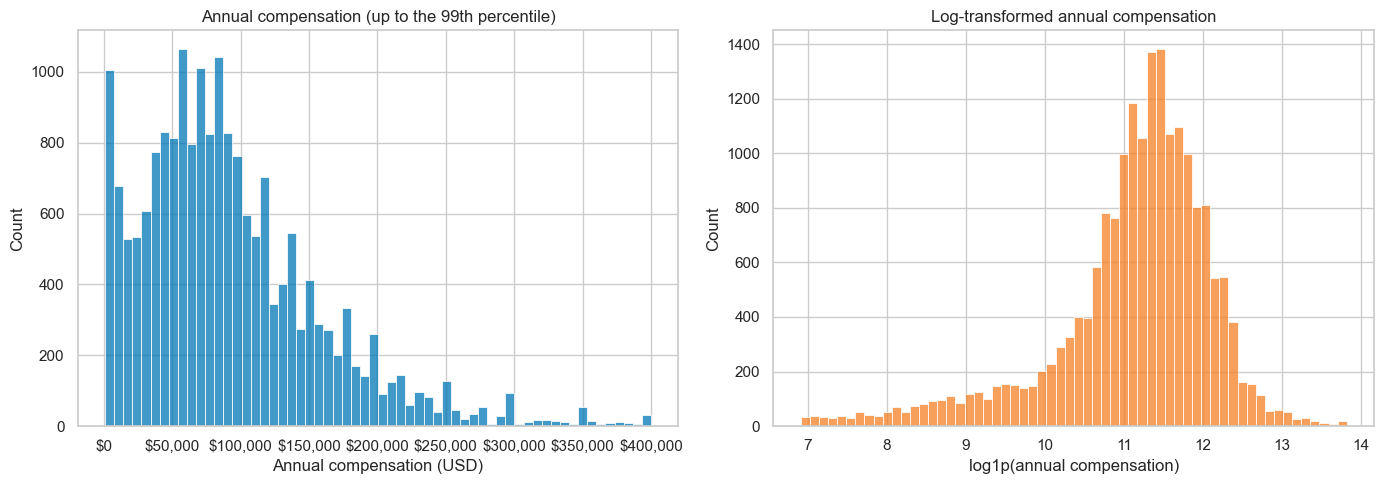

In [5]:
upper_99 = model_data[TARGET].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(
    model_data.loc[model_data[TARGET].le(upper_99), TARGET],
    bins=60,
    ax=axes[0],
    color="#0077B5",
)
axes[0].set_title("Annual compensation (up to the 99th percentile)")
axes[0].set_xlabel("Annual compensation (USD)")
axes[0].xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))

sns.histplot(np.log1p(model_data[TARGET]), bins=60, ax=axes[1], color="#F48024")
axes[1].set_title("Log-transformed annual compensation")
axes[1].set_xlabel("log1p(annual compensation)")

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "final_compensation_distribution.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## Question 1: How does compensation vary across experience, country, and role?

Medians are emphasized because compensation remains right-skewed even after
the plausibility filter. Country and role comparisons require at least 100
respondents; the figures show the highest-support groups to keep labels
readable. These are descriptive comparisons and do not adjust for the other
attributes.

In [6]:
def summarize_compensation(data, group_column, minimum_count=100):
    '''Return supported group counts, quartiles, and median compensation.'''
    summary = (
        data.groupby(group_column, observed=True)[TARGET]
        .agg(
            respondents="size",
            q25=lambda values: values.quantile(0.25),
            median="median",
            q75=lambda values: values.quantile(0.75),
        )
    )
    return summary.loc[summary["respondents"].ge(minimum_count)].copy()


experience_bins = [-0.1, 2, 5, 10, 15, 20, 30, np.inf]
experience_labels = ["0–2", "3–5", "6–10", "11–15", "16–20", "21–30", "31+"]
model_data["ExperienceBand"] = pd.cut(
    model_data["WorkExp"],
    bins=experience_bins,
    labels=experience_labels,
)

experience_summary = summarize_compensation(
    model_data.dropna(subset=["ExperienceBand"]),
    "ExperienceBand",
    minimum_count=1,
)
country_summary = summarize_compensation(model_data, "Country")
role_summary = summarize_compensation(model_data, "DevType")

experience_summary.to_csv(REPORT_DIR / "q1_experience_summary.csv")
country_summary.to_csv(REPORT_DIR / "q1_country_summary.csv")
role_summary.to_csv(REPORT_DIR / "q1_role_summary.csv")

display(experience_summary)

,respondents,q25,median,q75
ExperienceBand,,,,
0–2,1303,10702.5,30764.0,58367.0
3–5,2998,23203.0,46496.0,75410.0
6–10,4764,46406.0,75410.0,115720.0
11–15,3583,62015.0,92812.0,136485.0
16–20,2393,68134.0,102400.0,150819.0
21–30,2819,73232.0,110420.0,161191.0
31+,1017,78000.0,117082.0,165000.0


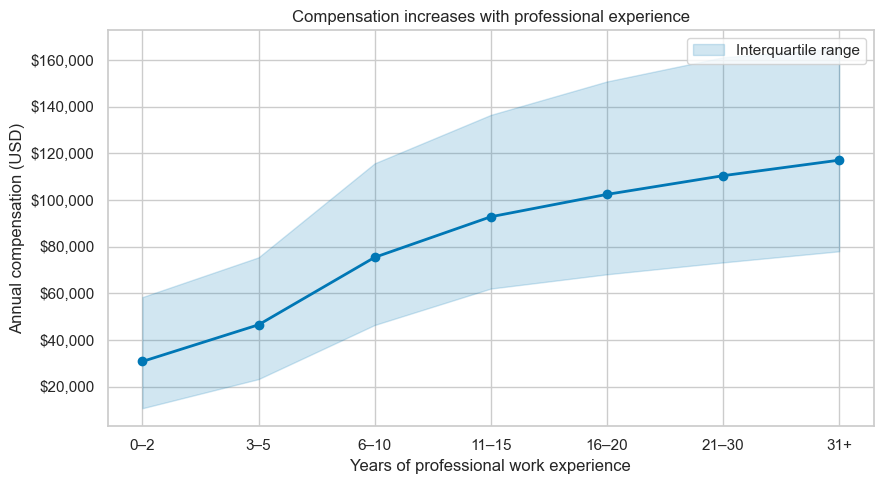

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    experience_summary.index.astype(str),
    experience_summary["median"],
    marker="o",
    linewidth=2,
    color="#0077B5",
)
ax.fill_between(
    range(len(experience_summary)),
    experience_summary["q25"].to_numpy(),
    experience_summary["q75"].to_numpy(),
    color="#0077B5",
    alpha=0.18,
    label="Interquartile range",
)
ax.set_title("Compensation increases with professional experience")
ax.set_xlabel("Years of professional work experience")
ax.set_ylabel("Annual compensation (USD)")
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "compensation_by_experience.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

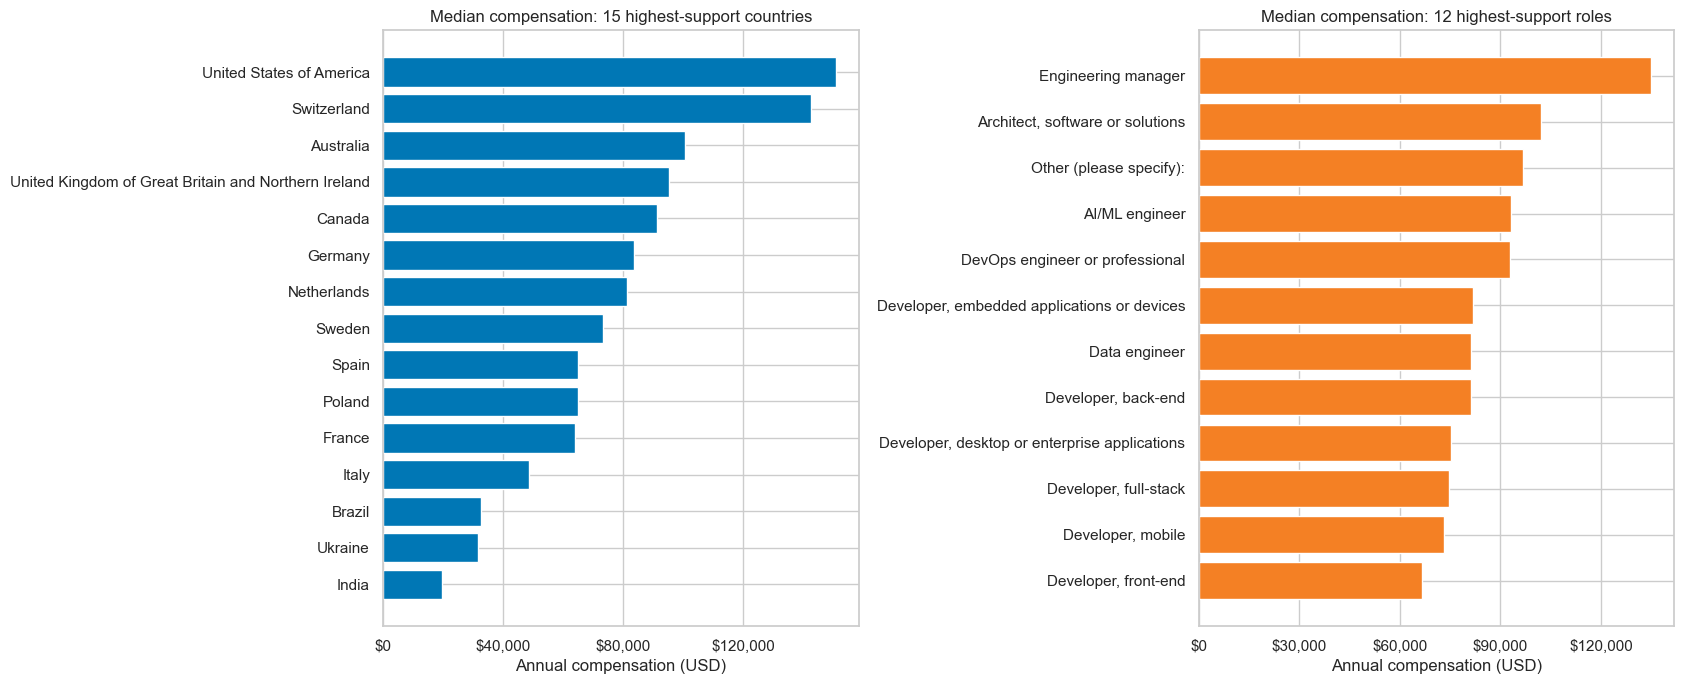

,respondents,q25,median,q75
Country,,,,
United States of America,4166,115000.0,151000.0,200000.0
Switzerland,324,117865.0,142592.0,172350.0
Australia,461,78011.0,100765.0,130019.0
United Kingdom of Great Britain and Northern Ireland,1232,69184.5,95299.0,134848.0
Canada,746,69310.0,91198.0,124029.0
Germany,1658,64968.0,83531.0,104413.0
Netherlands,499,62597.5,81210.0,106153.0
Sweden,411,59557.0,73375.0,85534.0
Spain,453,46116.0,64968.0,92812.0


,respondents,q25,median,q75
DevType,,,,
Engineering manager,495,89911.00,135000.0,190598.00
"Architect, software or solutions",1337,62648.00,102000.0,149756.00
Other (please specify):,302,56075.25,96872.0,150000.00
AI/ML engineer,294,51685.00,93062.0,152523.25
DevOps engineer or professional,480,59060.75,92812.0,145000.00
"Developer, embedded applications or devices",698,52207.00,81685.0,123993.00
"Developer, back-end",3686,46406.00,81210.0,130000.00
Data engineer,412,48931.50,81210.0,125000.00
"Developer, desktop or enterprise applications",1037,46331.00,75410.0,112000.00


In [8]:
country_plot = (
    country_summary.nlargest(15, "respondents")
    .sort_values("median")
)
role_plot = (
    role_summary.nlargest(12, "respondents")
    .sort_values("median")
)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
axes[0].barh(country_plot.index, country_plot["median"], color="#0077B5")
axes[0].set_title("Median compensation: 15 highest-support countries")
axes[0].set_xlabel("Annual compensation (USD)")
axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[0].xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))

axes[1].barh(role_plot.index, role_plot["median"], color="#F48024")
axes[1].set_title("Median compensation: 12 highest-support roles")
axes[1].set_xlabel("Annual compensation (USD)")
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "compensation_by_country_and_role.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

display(country_plot.sort_values("median", ascending=False))
display(role_plot.sort_values("median", ascending=False))

## CRISP-DM 3: Data Preparation

Numeric features are median-imputed with missingness indicators and scaled.
Categorical features receive an explicit `Missing` level and training-fold
rare-category handling. Semicolon-delimited technology answers are converted
to binary indicators only when at least 200 training respondents selected the
technology. The vocabulary is learned inside each training fold to prevent
leakage.

The target is transformed with `log1p`. A fixed, country-stratified 80/20 split
creates 15,220 training rows and 3,805 held-out test rows. `CompTotal`,
`Currency`, `JobSat`, identifiers, and free-text responses are excluded from
the predictors.

In [9]:
numeric_features = ["WorkExp", "YearsCode"]

categorical_features = [
    "Age",
    "EdLevel",
    "Employment",
    "DevType",
    "OrgSize",
    "ICorPM",
    "RemoteWork",
    "Industry",
    "Country",
    "AISelect",
    "AIAgents",
    "LanguageChoice",
    "DatabaseChoice",
    "PlatformChoice",
    "WebframeChoice",
]

multi_select_features = [
    "LanguageHaveWorkedWith",
    "DatabaseHaveWorkedWith",
    "PlatformHaveWorkedWith",
    "WebframeHaveWorkedWith",
]

feature_columns = (
    numeric_features + categorical_features + multi_select_features
)

X = model_data[feature_columns].copy()
y_usd = model_data[TARGET].astype(float)
y_log = np.log1p(y_usd)

# A low-support country stratum keeps rare countries represented in both sets.
country_counts = X["Country"].value_counts()
split_strata = X["Country"].where(
    X["Country"].map(country_counts).ge(20),
    "Other low-support countries",
)

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=split_strata,
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training rows: 15,220
Test rows: 3,805


In [10]:
numeric_pipeline = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(strategy="median", add_indicator=True),
        ),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(strategy="constant", fill_value="Missing"),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=100,
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
        (
            "technology",
            MultiSelectEncoder(min_frequency=200),
            multi_select_features,
        ),
    ],
    remainder="drop",
    sparse_threshold=0.0,
    verbose_feature_names_out=False,
)

## CRISP-DM 4: Modeling

The comparison covers three different model families plus a median baseline:

- Ridge regression: regularized linear relationships;
- Extra Trees: randomized tree bagging; and
- Histogram Gradient Boosting: sequential nonlinear learning.

Ridge evaluates four alpha values. Extra Trees and gradient boosting use
bounded randomized searches of eight and ten parameter combinations,
respectively. Every candidate uses the same five-fold splits and minimizes
cross-validated log MAE. The held-out test set is not used to select
hyperparameters.

In [11]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ridge_pipeline = Pipeline(
    [
        ("preprocess", clone(preprocessor)),
        ("model", Ridge()),
    ]
)

ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid={"model__alpha": [0.1, 1.0, 10.0, 100.0]},
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=1,
    refit=True,
)
ridge_search.fit(X_train, y_train_log)

print("Best Ridge alpha:", ridge_search.best_params_["model__alpha"])
print("Best Ridge CV log MAE:", -ridge_search.best_score_)

Best Ridge alpha: 10.0
Best Ridge CV log MAE: 0.46856571935699226


In [12]:
extra_trees_pipeline = Pipeline(
    [
        ("preprocess", clone(preprocessor)),
        (
            "model",
            ExtraTreesRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

extra_trees_search = RandomizedSearchCV(
    extra_trees_pipeline,
    param_distributions={
        "model__n_estimators": [250, 400, 600],
        "model__max_depth": [None, 20, 40, 60],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", 0.5, 0.8, 1.0],
    },
    n_iter=8,
    scoring="neg_mean_absolute_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    refit=True,
    return_train_score=False,
)
extra_trees_search.fit(X_train, y_train_log)

print("Best Extra Trees parameters:", extra_trees_search.best_params_)
print("Best Extra Trees CV log MAE:", -extra_trees_search.best_score_)

Best Extra Trees parameters: {'model__n_estimators': 250, 'model__min_samples_leaf': 5, 'model__max_features': 0.5, 'model__max_depth': None}
Best Extra Trees CV log MAE: 0.4508473101715227


In [13]:
hgb_pipeline = Pipeline(
    [
        ("preprocess", clone(preprocessor)),
        (
            "model",
            HistGradientBoostingRegressor(
                loss="absolute_error",
                early_stopping=True,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

hgb_search = RandomizedSearchCV(
    hgb_pipeline,
    param_distributions={
        "model__learning_rate": [0.04, 0.06, 0.08, 0.10],
        "model__max_iter": [150, 220, 300],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__min_samples_leaf": [20, 40, 80],
        "model__l2_regularization": [0.0, 1.0, 5.0],
    },
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    refit=True,
    return_train_score=False,
)
hgb_search.fit(X_train, y_train_log)

print("Best HGB parameters:", hgb_search.best_params_)
print("Best HGB CV log MAE:", -hgb_search.best_score_)

Best HGB parameters: {'model__min_samples_leaf': 40, 'model__max_leaf_nodes': 63, 'model__max_iter': 150, 'model__learning_rate': 0.1, 'model__l2_regularization': 1.0}
Best HGB CV log MAE: 0.42649907344001187


In [14]:
searches = {
    "Ridge": ridge_search,
    "Extra Trees": extra_trees_search,
    "Histogram gradient boosting": hgb_search,
}


def summarize_search(name, search):
    '''Summarize the best cross-validated candidate from one model family.'''
    best_index = search.best_index_
    results = search.cv_results_
    return {
        "Model": name,
        "CV log MAE": -search.best_score_,
        "CV log MAE std": results["std_test_score"][best_index],
        "Mean fit time per fold (s)": results["mean_fit_time"][best_index],
        "Best parameters": str(search.best_params_),
    }

cv_summary = pd.DataFrame(
    [summarize_search(name, search) for name, search in searches.items()]
).set_index("Model")
cv_summary.to_csv(REPORT_DIR / "cross_validation_summary.csv")

search_detail_frames = []
for name, search in searches.items():
    detail = pd.DataFrame(search.cv_results_)[
        [
            "params",
            "mean_test_score",
            "std_test_score",
            "rank_test_score",
            "mean_fit_time",
        ]
    ].copy()
    detail.insert(0, "Model", name)
    detail["CV log MAE"] = -detail.pop("mean_test_score")
    detail = detail.rename(
        columns={
            "std_test_score": "CV log MAE std",
            "rank_test_score": "Rank within family",
            "mean_fit_time": "Mean fit time per fold (s)",
        }
    )
    search_detail_frames.append(detail)

search_details = pd.concat(search_detail_frames, ignore_index=True)
search_details.to_csv(REPORT_DIR / "hyperparameter_search_results.csv", index=False)
cv_summary

,CV log MAE,CV log MAE std,Mean fit time per fold (s),Best parameters
Model,,,,
Ridge,0.468566,0.007559,0.525941,{'model__alpha': 10.0}
Extra Trees,0.450847,0.010705,4.628911,"{'model__n_estimators': 250, 'model__min_sampl..."
Histogram gradient boosting,0.426499,0.012536,5.557714,"{'model__min_samples_leaf': 40, 'model__max_le..."


## Question 2: Which technologies have adjusted compensation associations?

Ridge coefficients provide direction after conditioning on the other encoded
survey variables. Because the target is logarithmic, coefficients are
converted to approximate percentage differences. These are predictive,
conditional associations—not causal technology premiums.

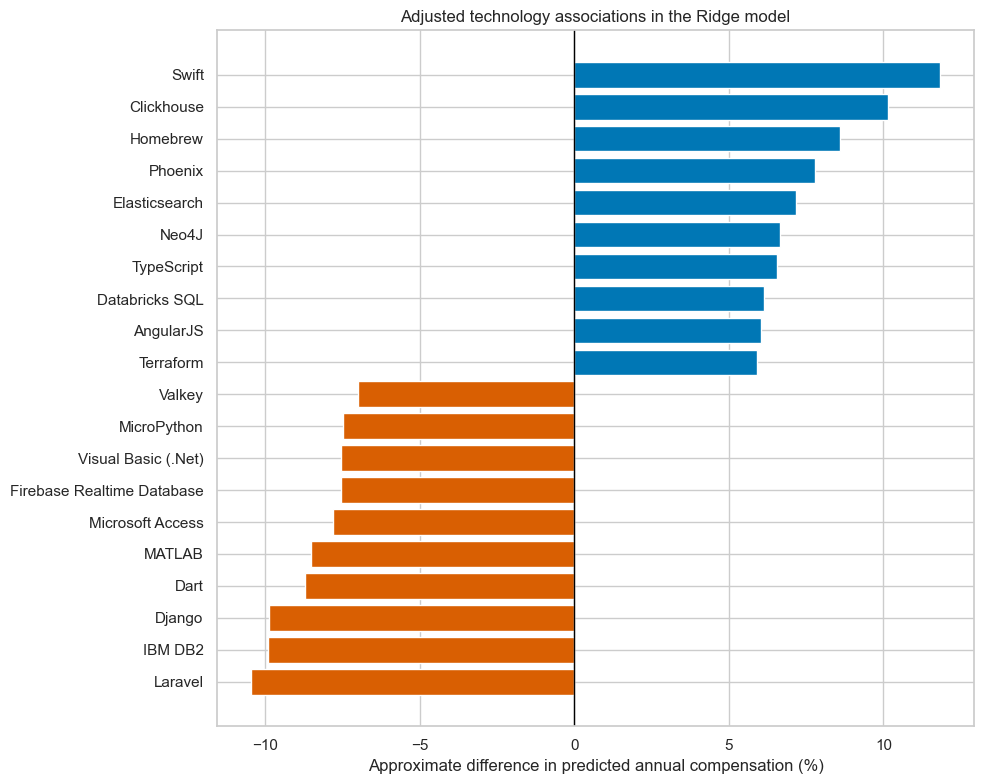

,technology_family,technology,approximate_percent_difference
0,Language,Swift,11.816664
1,Database,Clickhouse,10.142013
2,Platform,Homebrew,8.591776
3,Webframe,Phoenix,7.798986
4,Database,Elasticsearch,7.187590
5,Database,Neo4J,6.640247
6,Language,TypeScript,6.566298
7,Database,Databricks SQL,6.144673
8,Webframe,AngularJS,6.025453
9,Platform,Terraform,5.897008


In [15]:
ridge_model = ridge_search.best_estimator_
ridge_preprocessor = ridge_model.named_steps["preprocess"]
ridge_estimator = ridge_model.named_steps["model"]
ridge_feature_names = ridge_preprocessor.get_feature_names_out()

ridge_coefficients = pd.DataFrame(
    {
        "feature": ridge_feature_names,
        "coefficient_log": ridge_estimator.coef_,
    }
)
technology_coefficients = ridge_coefficients.loc[
    ridge_coefficients["feature"].str.contains("HaveWorkedWith__", regex=False)
].copy()
technology_coefficients["approximate_percent_difference"] = 100 * (
    np.exp(technology_coefficients["coefficient_log"]) - 1
)
technology_coefficients["technology_family"] = (
    technology_coefficients["feature"].str.split("HaveWorkedWith__").str[0]
)
technology_coefficients["technology"] = (
    technology_coefficients["feature"].str.split("HaveWorkedWith__").str[1]
)
technology_coefficients = technology_coefficients.loc[
    technology_coefficients["technology"] != "Missing"
].copy()
technology_coefficients = technology_coefficients.sort_values(
    "coefficient_log",
    ascending=False,
).reset_index(drop=True)
technology_coefficients.to_csv(
    REPORT_DIR / "technology_adjusted_associations.csv",
    index=False,
)

association_extremes = pd.concat(
    [technology_coefficients.head(10), technology_coefficients.tail(10)]
).sort_values("approximate_percent_difference")

fig, ax = plt.subplots(figsize=(10, 8))
colors = np.where(
    association_extremes["approximate_percent_difference"] >= 0,
    "#0077B5",
    "#D95F02",
)
ax.barh(
    association_extremes["technology"],
    association_extremes["approximate_percent_difference"],
    color=colors,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Adjusted technology associations in the Ridge model")
ax.set_xlabel("Approximate difference in predicted annual compensation (%)")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "technology_adjusted_associations.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

technology_coefficients.head(12)[
    ["technology_family", "technology", "approximate_percent_difference"]
]

## Question 3: How accurately can compensation be predicted?

The primary metric is MAE on the log target, which treats proportional errors
more consistently across global salary levels. Its exponent is shown as a
typical multiplicative error. Log R² and back-transformed USD errors provide
additional context.

In [16]:
def evaluate_predictions(name, true_log, predicted_log):
    '''Return log-scale and back-transformed USD metrics.'''
    true_usd = np.expm1(true_log)
    predicted_usd = np.expm1(predicted_log)
    log_mae = mean_absolute_error(true_log, predicted_log)

    return {
        "Model": name,
        "Test log MAE": log_mae,
        "Typical multiplicative error": np.exp(log_mae),
        "Test log R2": r2_score(true_log, predicted_log),
        "Test USD MAE": mean_absolute_error(true_usd, predicted_usd),
        "Test USD median AE": median_absolute_error(
            true_usd,
            predicted_usd,
        ),
    }


baseline_prediction = np.full(len(y_test_log), y_train_log.median())

ridge_model = ridge_search.best_estimator_
ridge_prediction = ridge_model.predict(X_test)

extra_trees_model = extra_trees_search.best_estimator_
extra_trees_prediction = extra_trees_model.predict(X_test)

hgb_model = hgb_search.best_estimator_
hgb_prediction = hgb_model.predict(X_test)

test_results = pd.DataFrame(
    [
        evaluate_predictions("Median baseline", y_test_log, baseline_prediction),
        evaluate_predictions("Ridge", y_test_log, ridge_prediction),
        evaluate_predictions(
            "Extra Trees",
            y_test_log,
            extra_trees_prediction,
        ),
        evaluate_predictions(
            "Histogram gradient boosting",
            y_test_log,
            hgb_prediction,
        ),
    ]
).set_index("Model")

test_results.to_csv(REPORT_DIR / "model_comparison.csv")
test_results

,Test log MAE,Typical multiplicative error,Test log R2,Test USD MAE,Test USD median AE
Model,,,,,
Median baseline,0.735658,2.086855,-0.038646,55289.791327,39364.000000
Ridge,0.460265,1.584495,0.560945,34747.925209,20214.371533
Extra Trees,0.452594,1.572385,0.553976,33832.277628,19111.791785
Histogram gradient boosting,0.422208,1.525325,0.563932,31870.573994,17923.626805


In [17]:
cv_log_mae = {
    name: -search.best_score_
    for name, search in searches.items()
}
best_model_name = min(cv_log_mae, key=cv_log_mae.get)
candidate_models = {
    "Ridge": ridge_model,
    "Extra Trees": extra_trees_model,
    "Histogram gradient boosting": hgb_model,
}
best_model = candidate_models[best_model_name]
best_prediction = best_model.predict(X_test)

print("Selected model by cross-validated log MAE:", best_model_name)

Selected model by cross-validated log MAE: Histogram gradient boosting


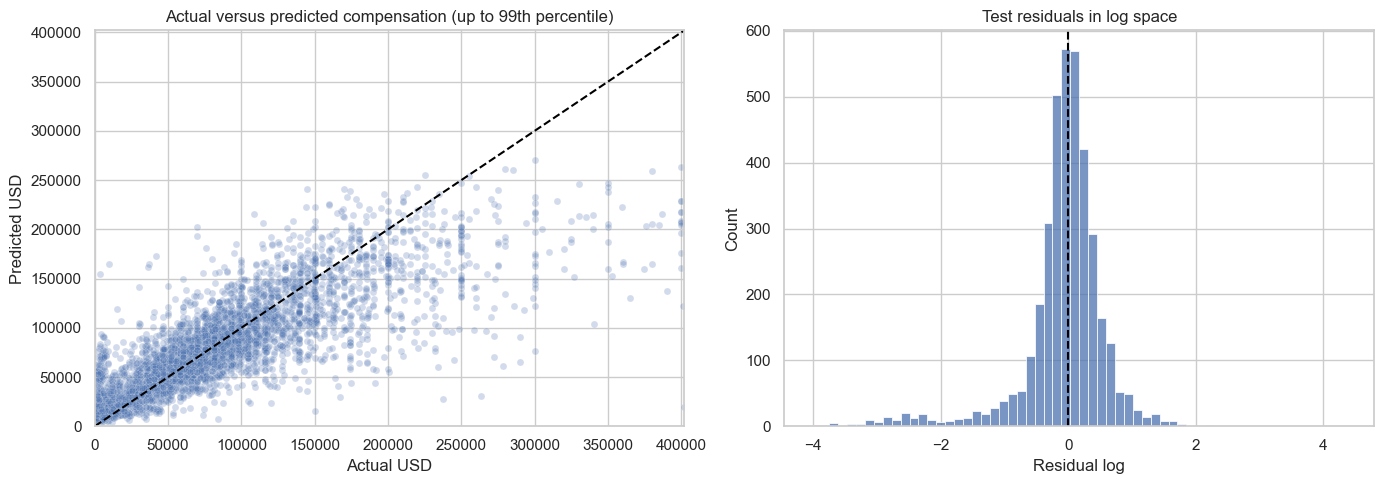

In [18]:
prediction_frame = pd.DataFrame(
    {
        "Actual USD": np.expm1(y_test_log),
        "Predicted USD": np.expm1(best_prediction),
        "Residual log": y_test_log - best_prediction,
    }
)

plot_limit = prediction_frame[["Actual USD", "Predicted USD"]].quantile(0.99).max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=prediction_frame,
    x="Actual USD",
    y="Predicted USD",
    alpha=0.25,
    s=25,
    ax=axes[0],
)
axes[0].plot([0, plot_limit], [0, plot_limit], "--", color="black")
axes[0].set_xlim(0, plot_limit)
axes[0].set_ylim(0, plot_limit)
axes[0].set_title("Actual versus predicted compensation (up to 99th percentile)")

sns.histplot(prediction_frame["Residual log"], bins=60, ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Test residuals in log space")

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "model_test_diagnostics.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

### Which features contribute most to predictive accuracy?

Permutation importance is computed on the transformed held-out test data. It
measures the increase in log MAE when one encoded feature is shuffled. It is a
predictive importance measure, not a causal effect, and correlated features
may divide their importance.

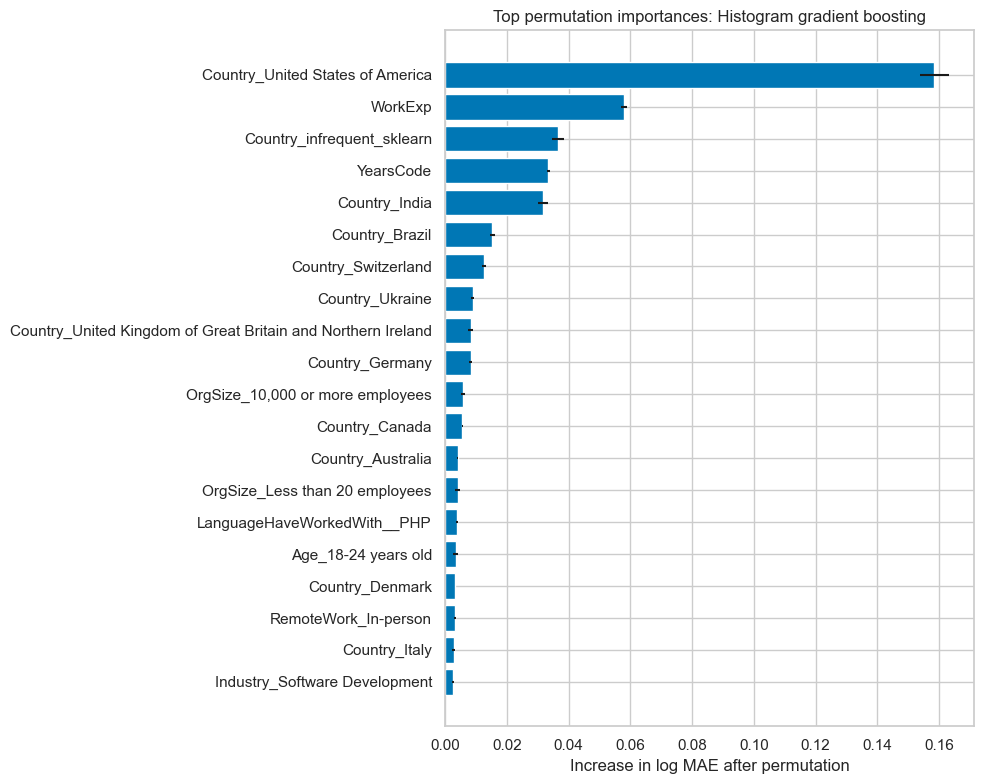

,feature,importance_mean,importance_std
0,Country_United States of America,0.158359,0.004737
1,WorkExp,0.057925,0.001084
2,Country_infrequent_sklearn,0.036552,0.002039
3,YearsCode,0.033400,0.000439
4,Country_India,0.031809,0.001642
5,Country_Brazil,0.015286,0.000762
6,Country_Switzerland,0.012593,0.000595
7,Country_Ukraine,0.008937,0.000460
8,Country_United Kingdom of Great Britain and No...,0.008249,0.000708
9,Country_Germany,0.008205,0.000489


In [19]:
best_preprocessor = best_model.named_steps["preprocess"]
best_estimator = best_model.named_steps["model"]
X_test_transformed = best_preprocessor.transform(X_test)
feature_names = best_preprocessor.get_feature_names_out()

importance = permutation_importance(
    best_estimator,
    X_test_transformed,
    y_test_log,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importance_frame = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "importance_mean": importance.importances_mean,
            "importance_std": importance.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
importance_frame.to_csv(REPORT_DIR / "feature_importance.csv", index=False)

top_importance = importance_frame.head(20).sort_values(
    "importance_mean",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    top_importance["feature"],
    top_importance["importance_mean"],
    xerr=top_importance["importance_std"],
    color="#0077B5",
)
ax.set_title(f"Top permutation importances: {best_model_name}")
ax.set_xlabel("Increase in log MAE after permutation")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "model_feature_importance.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

importance_frame.head(25)

## Question 4: What does the model predict for hypothetical developers?

The three synthetic profiles use valid survey categories and hold country,
industry, organization size, and work arrangement constant. Career stage,
role, responsibility, and technology portfolios vary together to create
readable whole-profile scenarios. The gaps are not causal effects of promotion
or experience and are not salary guarantees.

In [20]:
scenarios = pd.DataFrame(
    [
        {
            "Scenario": "Early-career full-stack IC",
            "WorkExp": 3,
            "YearsCode": 6,
            "Age": "25-34 years old",
            "EdLevel": "Bachelor’s degree (B.A., B.S., B.Eng., etc.)",
            "Employment": "Employed",
            "DevType": "Developer, full-stack",
            "OrgSize": "100 to 499 employees",
            "ICorPM": "Individual contributor",
            "RemoteWork": "Hybrid (some in-person, leans heavy to flexibility)",
            "Industry": "Software Development",
            "Country": "United States of America",
            "AISelect": "Yes, I use AI tools weekly",
            "AIAgents": "No, and I don't plan to",
            "LanguageChoice": "Yes",
            "DatabaseChoice": "Yes",
            "PlatformChoice": "Yes",
            "WebframeChoice": "Yes",
            "LanguageHaveWorkedWith": "HTML/CSS;JavaScript;SQL;TypeScript",
            "DatabaseHaveWorkedWith": "PostgreSQL",
            "PlatformHaveWorkedWith": "Docker;npm",
            "WebframeHaveWorkedWith": "Node.js;React",
        },
        {
            "Scenario": "Experienced back-end IC",
            "WorkExp": 10,
            "YearsCode": 14,
            "Age": "35-44 years old",
            "EdLevel": "Bachelor’s degree (B.A., B.S., B.Eng., etc.)",
            "Employment": "Employed",
            "DevType": "Developer, back-end",
            "OrgSize": "100 to 499 employees",
            "ICorPM": "Individual contributor",
            "RemoteWork": "Hybrid (some in-person, leans heavy to flexibility)",
            "Industry": "Software Development",
            "Country": "United States of America",
            "AISelect": "Yes, I use AI tools weekly",
            "AIAgents": "No, and I don't plan to",
            "LanguageChoice": "Yes",
            "DatabaseChoice": "Yes",
            "PlatformChoice": "Yes",
            "WebframeChoice": "Yes",
            "LanguageHaveWorkedWith": "Java;Python;SQL",
            "DatabaseHaveWorkedWith": "PostgreSQL;Redis",
            "PlatformHaveWorkedWith": (
                "Amazon Web Services (AWS);Docker;Kubernetes;Terraform"
            ),
            "WebframeHaveWorkedWith": "FastAPI;Spring Boot",
        },
        {
            "Scenario": "Experienced engineering manager",
            "WorkExp": 15,
            "YearsCode": 20,
            "Age": "35-44 years old",
            "EdLevel": "Bachelor’s degree (B.A., B.S., B.Eng., etc.)",
            "Employment": "Employed",
            "DevType": "Engineering manager",
            "OrgSize": "100 to 499 employees",
            "ICorPM": "People manager",
            "RemoteWork": "Hybrid (some in-person, leans heavy to flexibility)",
            "Industry": "Software Development",
            "Country": "United States of America",
            "AISelect": "Yes, I use AI tools weekly",
            "AIAgents": "Yes, I use AI agents at work monthly or infrequently",
            "LanguageChoice": "Yes",
            "DatabaseChoice": "Yes",
            "PlatformChoice": "Yes",
            "WebframeChoice": "Yes",
            "LanguageHaveWorkedWith": "Java;Python;SQL",
            "DatabaseHaveWorkedWith": "PostgreSQL;Redis",
            "PlatformHaveWorkedWith": (
                "Amazon Web Services (AWS);Docker;Kubernetes;Terraform"
            ),
            "WebframeHaveWorkedWith": "FastAPI;Spring Boot",
        },
    ]
).set_index("Scenario")

scenario_prediction = np.expm1(best_model.predict(scenarios[feature_columns]))
scenario_results = scenarios[["Country", "DevType", "WorkExp", "ICorPM"]].copy()
scenario_results["Predicted annual compensation (USD)"] = scenario_prediction
scenario_results.to_csv(REPORT_DIR / "scenario_predictions.csv")
scenario_results

,Country,DevType,WorkExp,ICorPM,Predicted annual compensation (USD)
Scenario,,,,,
Early-career full-stack IC,United States of America,"Developer, full-stack",3,Individual contributor,102239.588739
Experienced back-end IC,United States of America,"Developer, back-end",10,Individual contributor,194938.605040
Experienced engineering manager,United States of America,Engineering manager,15,People manager,214370.832525


## CRISP-DM 5: Evaluation and Sensitivity Analysis

The approved sensitivity range uses USD 2,500–500,000. Ridge is refitted on
that range using the same alpha and pipeline design. This checks whether the
headline linear-model performance depends strongly on the broader tail rule.
The samples and test splits differ, so this is a robustness check rather than a
controlled model benchmark.

In [21]:
strict_data = survey.loc[
    professional
    & working
    & survey[TARGET].between(2_500, 500_000)
].copy()

strict_X = strict_data[feature_columns]
strict_y_log = np.log1p(strict_data[TARGET].astype(float))
strict_country_counts = strict_X["Country"].value_counts()
strict_strata = strict_X["Country"].where(
    strict_X["Country"].map(strict_country_counts).ge(20),
    "Other low-support countries",
)

strict_X_train, strict_X_test, strict_y_train, strict_y_test = train_test_split(
    strict_X,
    strict_y_log,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=strict_strata,
)

strict_ridge = Pipeline(
    [
        ("preprocess", clone(preprocessor)),
        (
            "model",
            Ridge(alpha=ridge_search.best_params_["model__alpha"]),
        ),
    ]
).fit(strict_X_train, strict_y_train)

strict_prediction = strict_ridge.predict(strict_X_test)
sensitivity_comparison = pd.DataFrame(
    [
        evaluate_predictions("Primary range Ridge", y_test_log, ridge_prediction),
        evaluate_predictions(
            "Strict range Ridge",
            strict_y_test,
            strict_prediction,
        ),
    ]
).set_index("Model")
sensitivity_comparison.to_csv(REPORT_DIR / "sensitivity_comparison.csv")
sensitivity_comparison

,Test log MAE,Typical multiplicative error,Test log R2,Test USD MAE,Test USD median AE
Model,,,,,
Primary range Ridge,0.460265,1.584495,0.560945,34747.925209,20214.371533
Strict range Ridge,0.400667,1.492820,0.589146,30778.616898,18810.621304


## Conclusions and Limitations

1. Compensation rises with experience and varies substantially across
   countries and roles.
2. Country and experience dominate individual technologies as predictive
   signals. Technology coefficients remain conditional associations only.
3. Histogram Gradient Boosting wins the common CV comparison. On the test set,
   its log MAE is about 0.422, equivalent to a typical multiplicative error of
   about 1.53×; log R² is about 0.564.
4. Synthetic profiles illustrate model behavior but are not individual salary
   recommendations.

The survey is observational, self-reported, and self-selected. Global USD
comparisons do not adjust for purchasing power or local cost of living.
Unmeasured employer, specialty, performance, and labor-market factors remain.
Back-transformed point predictions also compress the upper tail. The model is
therefore useful for population-level pattern discovery, not compensation
decisions about individuals.